In [1]:

import numpy as np
import matplotlib.pyplot as plt

# 3.1 The Third Cumulant

### a)
To show $\sigma^2 =\left\langle (x-\mu)^2 \right\rangle =\left\langle x^2 \right\rangle- \left\langle x\right\rangle^2$

$\left\langle (x-\mu)^2 \right\rangle = \left\langle (x-\left\langle x\right\rangle)^2 \right\rangle = \left\langle x^2- 2x\left\langle x\right\rangle+\left\langle x\right\rangle^2\right\rangle = \left\langle x^2\right\rangle- 2\left\langle x\right\rangle\left\langle x\right\rangle+\left\langle x\right\rangle^2 =\left\langle x^2 \right\rangle- \left\langle x\right\rangle^2$


### b)
To show: $G(k)=\text{exp}(ik\mu-\frac{k^2}{2}\sigma^2-\frac{ik^3}{6}\left\langle (x-\mu)^3 \right\rangle+\mathcal{O}(k^4))$

We have $\left\langle (x-\mu)^3 \right\rangle = \left\langle x^3 \right\rangle-3\mu\left\langle x^2\right\rangle + 3\mu\left\langle x \right\rangle^2 - \mu ^3  = \left\langle x^3 \right\rangle - 3\mu \sigma^2 - \mu ^3  $

With
\begin{align}
    G_x(k)
    &= \sum_{n=0}^{\infty} \frac{i^n k^n}{n!} \left\langle x^n \right\rangle
\end{align}

We calculate:

\begin{align}
    G_x(k)
    &= 1 + ik \mu - \frac{1}{2} \left\langle x^2 \right\rangle k^2 -\frac{i}{6} \left\langle x^3 \right\rangle k^3\cdots
\\  &= 1 + ik \mu - \frac{1}{2} (\left\langle x^2 \right\rangle -  \left\langle x \right\rangle^2 + \left\langle x \right\rangle^2)k^2 -\frac{i}{6}( \left\langle x^3 \right\rangle - 3\mu \sigma^2 - \mu ^3+ 3\mu \sigma^2 + \mu ^3) k^3 +\cdots
\\  &= 1 + ik \mu - \frac{1}{2} (\sigma^2 + \mu^2)k^2 -\frac{ik^3}{6}(\left\langle (x-\mu)^3 \right\rangle + 3\mu \sigma^2 + \mu ^3)) + \cdots 
\\  &= \left(1 + ik \mu - \frac{1}{2} \mu^2 k^2 + \cdots \right) \left(1 - \frac{1}{2} \sigma^2k^2 + \cdots \right)  \left(1 -\frac{ik^3}{6}\left\langle (x-\mu)^3 \right\rangle\right) +\cdots
\\  &= e^{ik\mu} e^{- k^2\sigma^2/2} e^{- \frac{ik^3}{6}\left\langle (x-\mu)^3 \right\rangle} + \cdots
\\  &= \text{exp}(ik\mu-\frac{k^2}{2}\sigma^2-\frac{ik^3}{6}\left\langle (x-\mu)^3 \right\rangle+\mathcal{O}(k^4))
\end{align}

# 3.2 Evolution of the Sample Average

In [65]:
def Laplace_0_1(x):
    return 1/2 * np.exp(-np.abs(x))


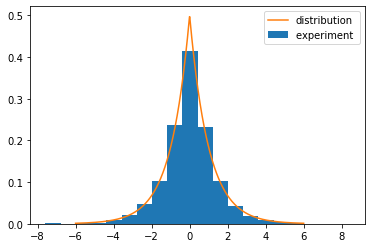

In [81]:
T = 2**11
y = np.linspace(-6,6,1000)
laplace_samples =  np.random.laplace(0, 1, T)
plt.hist(laplace_samples,density = True, label="experiment ",bins=20)
plt.plot(y,Laplace_0_1(y), label="distribution")
plt.legend()
plt.show()

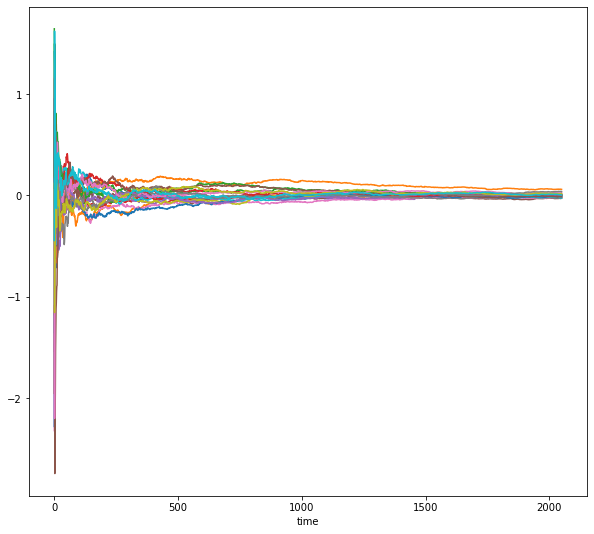

In [82]:
t = np.linspace(1,T+1,T)
fig, ax = plt.subplots(figsize=(10,9))
for a in range(20):
    laplace_samples =  np.random.laplace(0, 1, T)
    S_t = np.zeros(T)
    s =0
    for z in range(len(S_t)):
        s = s + laplace_samples[z]
        S_t[z] =s/(z+1)
    ax.plot(t,S_t)
    
ax.set_xlabel('time')
plt.show()


In [118]:
laplace_samples =  np.random.laplace(0, 1, (1000 ,T))
S_t_l = np.zeros((1000 ,T))
s = np.zeros(1000)
for z in range(1000):
    s = s + laplace_samples[:,z]

    S_t_l[:,z] =s/(z+1)


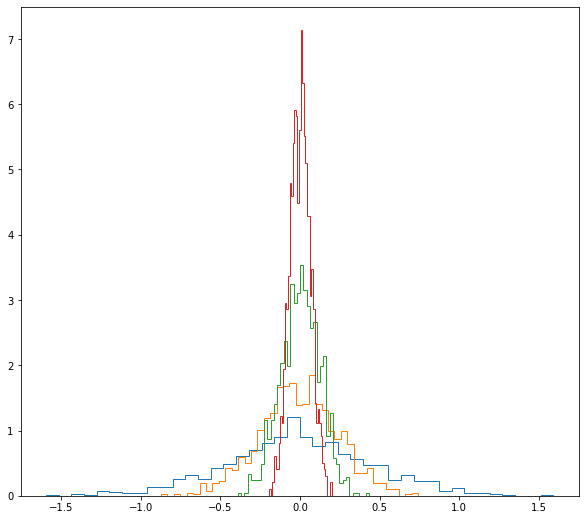

In [119]:
fig, ax = plt.subplots(figsize =(10,9))
ax.hist(S_t_l[:,8],histtype="step",density=True,bins =40)

ax.hist(S_t_l[:,32],histtype="step",density=True,bins =40)

ax.hist(S_t_l[:,128],histtype="step",density=True,bins =40)

ax.hist(S_t_l[:,512],histtype="step",density=True,bins =40)
plt.show()

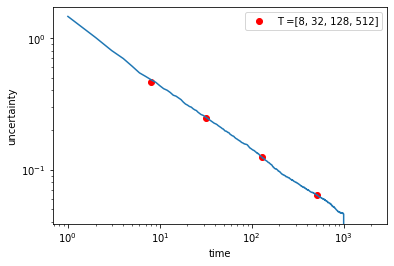

In [135]:

#laplace_samples_squared = laplace_samples**2
# Variance of Laplace: 2b² -> Here Variance =2
points = [8,32,128,512]
uncertainty = np.std(S_t_l, axis = 0)
#sigma_squared_t = ((laplace_samples_squared-laplace_samples.mean(axis=0))**2).mean(axis=0)

plt.plot(t, uncertainty)
plt.scatter(points,uncertainty[points],color ='red', label = f'T ={points}')
plt.legend()
plt.xlabel('time')
plt.ylabel('uncertainty')
plt.xscale('log')
plt.yscale('log')

# 3.3 A Long-Tailed Distribution

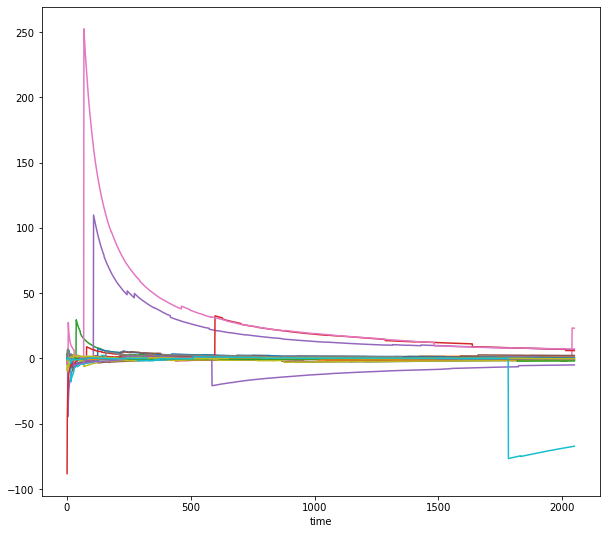

In [137]:
fig, ax = plt.subplots(figsize=(10,9))
for a in range(20):
    cauchy_samples =  np.random.standard_cauchy(T)
    S_t_c = np.zeros(T)
    s =0
    for z in range(len(S_t_c)):
        s = s + cauchy_samples[z]
        S_t_c[z] =s/(z+1)
    ax.plot(t,S_t_c)
    
ax.set_xlabel('time')
plt.show()


In [157]:
cauchy_samples =  np.random.standard_cauchy( (1000 ,T))
S_t_c = np.zeros((1000 ,T))
s = np.zeros(1000)
for z in range(1000):
    s = s + cauchy_samples[:,z]

    S_t_c[:,z] =s/(z+1)


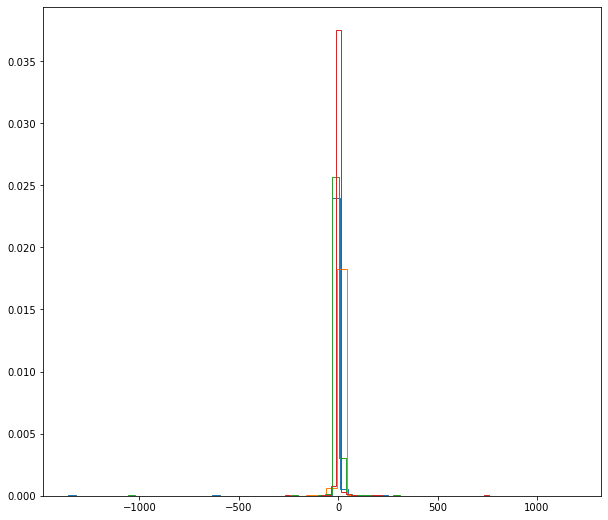

In [158]:
fig, ax = plt.subplots(figsize =(10,9))
ax.hist(S_t_c[:,8],histtype="step",density=True,bins =40)

ax.hist(S_t_c[:,32],histtype="step",density=True,bins =40)

ax.hist(S_t_c[:,128],histtype="step",density=True,bins =40)

ax.hist(S_t_c[:,512],histtype="step",density=True,bins =40)
plt.show()

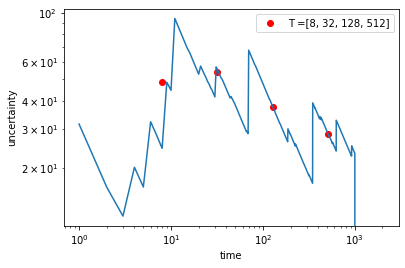

In [159]:


uncertainty = np.std(S_t_c, axis = 0)
plt.plot(t, uncertainty)
plt.scatter(points,uncertainty[points],color ='red', label = f'T ={points}')
plt.legend()
plt.xlabel('time')
plt.ylabel('uncertainty')
plt.xscale('log')
plt.yscale('log')

##### The central Limit theory states:

Suppose we draw $n$ iid variables from distribution $P$ with mean $\mu$ and variance $\sigma^2$, then for n large enough $$S_n = 1/n \sum_{j=0}^{n} x_j \sim \mathcal{N}(\mu,\frac{\sigma^2}{n})$$

The Cauchy-distribution fails the condition for the central limit theory since it doesn't have a defined mean and variance.

# 3.4 Preparing for Sampling the Ising Model

In [14]:
sigma = np.random.choice([-1,1], size=3)

def H1d(J,sigma):
    return J*(np.roll(sigma,-1)*sigma+np.roll(sigma,1)*sigma).sum()


print(sigma[len(sigma)-1])

def delH1d(J,sigma,x):
    if len(sigma)-1 in [x]:
        s = 2*J*(sigma[0]*sigma[x]+ sigma[x-1]*sigma[x])
    else: 
        s = 2*J*(sigma[x+1]*sigma[x]+ sigma[x-1]*sigma[x])
    return s
        

-1
